# Assignment 8

# Handwritten Digit Recognition using Artificial Neural Networks (ANN)

**Name:** Khushie Brahma

**Assignment Number:** Assignment 8

## Objective

The objective of this assignment is to develop an Artificial Neural Network (ANN) using TensorFlow/Keras to recognize handwritten digits (0–9) from the MNIST dataset. The model will be trained to classify digit images accurately and evaluated using standard classification metrics.

## 1: Import Required Libraries

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical

2026-07-30 23:51:05.108114: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


## 2: Load Dataset

In [2]:
df = pd.read_csv("../data/mnist_train.csv")

## 3: Display the First Five Records

In [3]:
df.head()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
0,5,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


## 4: Data Understanding

In [4]:
print("Dataset Shape:", df.shape)

Dataset Shape: (60000, 785)


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Columns: 785 entries, label to 28x28
dtypes: int64(785)
memory usage: 359.3 MB


In [6]:
df.describe()

,label,1x1,1x2,1x3,1x4,1x5,1x6,1x7,1x8,1x9,...,28x19,28x20,28x21,28x22,28x23,28x24,28x25,28x26,28x27,28x28
count,60000.000000,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,60000.0,...,60000.000000,60000.000000,60000.000000,60000.000000,60000.000000,60000.0000,60000.0,60000.0,60000.0,60000.0
mean,4.453933,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.200433,0.088867,0.045633,0.019283,0.015117,0.0020,0.0,0.0,0.0,0.0
std,2.889270,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,6.042472,3.956189,2.839845,1.686770,1.678283,0.3466,0.0,0.0,0.0,0.0
min,0.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
25%,2.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
50%,4.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
75%,7.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.0,0.0,0.0,0.0
max,9.000000,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,254.000000,254.000000,253.000000,253.000000,254.000000,62.0000,0.0,0.0,0.0,0.0


### Input Features

- Pixel values (pixel0 to pixel783)

### Target Variable

- label (Digits 0–9)

### Display a Sample Handwritten Digit

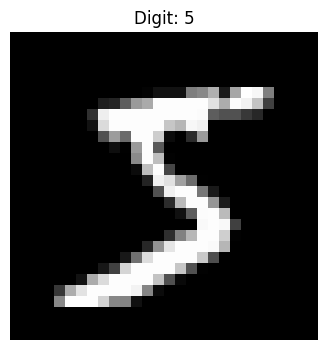

In [7]:
image = df.iloc[0, 1:].values.reshape(28, 28)

plt.figure(figsize=(4,4))
plt.imshow(image, cmap="gray")

plt.title(f"Digit: {df.iloc[0,0]}")
plt.axis("off")

plt.show()

### Observation

The MNIST dataset was successfully loaded into a Pandas DataFrame. It contains 784 pixel values representing each handwritten digit image and one target column (`label`) indicating the corresponding digit from 0 to 9. The dataset dimensions, summary information, and a sample digit visualization provide a clear understanding of the data before preprocessing.

## 5: Data Preprocessing

### Check for Missing Values

In [8]:
df.isnull().sum()

label    0
1x1      0
1x2      0
1x3      0
1x4      0
        ..
28x24    0
28x25    0
28x26    0
28x27    0
28x28    0
Length: 785, dtype: int64

### Separate Features and Target Variable

In [9]:
X = df.drop("label", axis=1)
y = df["label"]

In [10]:
print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (60000, 784)
Target Shape: (60000,)


### Normalize Pixel Values

In [11]:
X = X / 255.0

In [12]:
print("Minimum Pixel Value:", X.min().min())
print("Maximum Pixel Value:", X.max().max())

Minimum Pixel Value: 0.0
Maximum Pixel Value: 1.0


### Split the Dataset

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [14]:
print("Training Features:", X_train.shape)
print("Testing Features:", X_test.shape)

print("Training Labels:", y_train.shape)
print("Testing Labels:", y_test.shape)

Training Features: (48000, 784)
Testing Features: (12000, 784)
Training Labels: (48000,)
Testing Labels: (12000,)


### One-Hot Encode the Target Labels

In [15]:
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

In [16]:
print("One-Hot Encoded Training Labels:", y_train.shape)
print("One-Hot Encoded Testing Labels:", y_test.shape)

One-Hot Encoded Training Labels: (48000, 10)
One-Hot Encoded Testing Labels: (12000, 10)


### Observation

The MNIST dataset was successfully preprocessed by checking for missing values, separating the input features and target labels, normalizing the pixel values to the range **0–1**, splitting the dataset into **80% training** and **20% testing** sets, and converting the target labels into one-hot encoded vectors. These preprocessing steps prepare the data for efficient training of the Artificial Neural Network (ANN).

## 6: Model Development

### Build the Artificial Neural Network (ANN)

In [17]:
model = Sequential()

# Input Layer + Hidden Layer 1
model.add(Dense(128, activation="relu", input_shape=(784,)))

# Hidden Layer 2
model.add(Dense(64, activation="relu"))

# Output Layer
model.add(Dense(10, activation="softmax"))

In [18]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 128)               100480    
                                                                 
 dense_1 (Dense)             (None, 64)                8256      
                                                                 
 dense_2 (Dense)             (None, 10)                650       
                                                                 
Total params: 109386 (427.29 KB)
Trainable params: 109386 (427.29 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Compile the Model

In [19]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

### Train the Model

In [20]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

Epoch 1/10
1200/1200 [==============================] - 16s 11ms/step - loss: 0.2984 - accuracy: 0.9123 - val_loss: 0.1599 - val_accuracy: 0.9541
Epoch 2/10
1200/1200 [==============================] - 20s 17ms/step - loss: 0.1258 - accuracy: 0.9629 - val_loss: 0.1263 - val_accuracy: 0.9625
Epoch 3/10
1200/1200 [==============================] - 11s 9ms/step - loss: 0.0880 - accuracy: 0.9741 - val_loss: 0.1098 - val_accuracy: 0.9670
Epoch 4/10
1200/1200 [==============================] - 10s 8ms/step - loss: 0.0663 - accuracy: 0.9802 - val_loss: 0.0921 - val_accuracy: 0.9721
Epoch 5/10
1200/1200 [==============================] - 13s 11ms/step - loss: 0.0507 - accuracy: 0.9845 - val_loss: 0.0934 - val_accuracy: 0.9707
Epoch 6/10
1200/1200 [==============================] - 12s 10ms/step - loss: 0.0367 - accuracy: 0.9886 - val_loss: 0.0987 - val_accuracy: 0.9715
Epoch 7/10
1200/1200 [==============================] - 9s 7ms/step - loss: 0.0342 - accuracy: 0.9885 - val_loss: 0.1079 - val

### Predict Handwritten Digits

In [21]:
y_pred = model.predict(X_test)

375/375 [==============================] - 3s 8ms/step


In [22]:
y_pred_classes = np.argmax(y_pred, axis=1)
y_true = np.argmax(y_test, axis=1)

In [23]:
print("First 10 Predicted Digits:")
print(y_pred_classes[:10])

print("\nFirst 10 Actual Digits:")
print(y_true[:10])

First 10 Predicted Digits:
[7 3 8 9 3 9 7 7 5 4]

First 10 Actual Digits:
[7 3 8 9 3 9 7 7 5 4]


### Observation

The Artificial Neural Network (ANN) was successfully built using two hidden layers with 128 and 64 neurons respectively, both using the ReLU activation function. The output layer consists of 10 neurons with the Softmax activation function to classify handwritten digits from 0 to 9. The model was compiled using the Adam optimizer and Categorical Crossentropy loss function, trained for 10 epochs, and used to generate predictions on the test dataset.

## 7: Model Evaluation

### Evaluate the Model

In [24]:
test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

Test Loss: 0.1008
Test Accuracy: 0.9756


### Confusion Matrix

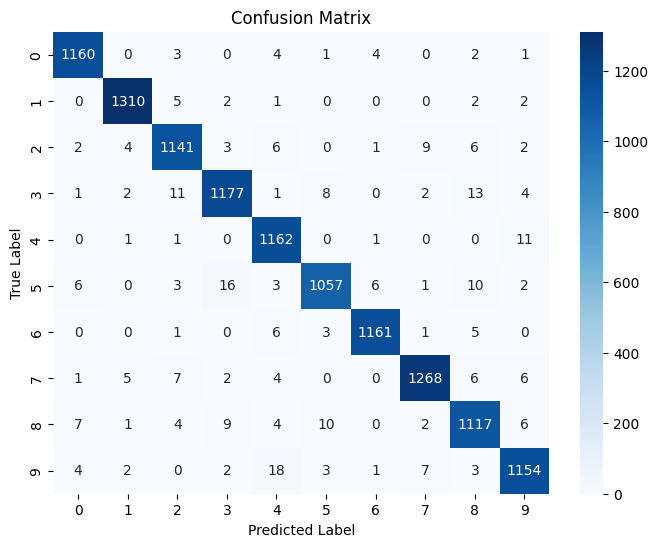

In [25]:
cm = confusion_matrix(y_true, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.savefig("../images/confusion_matrix.png", dpi=300, bbox_inches="tight")

plt.show()

### Classification Report

In [26]:
print(classification_report(y_true, y_pred_classes))

              precision    recall  f1-score   support

           0       0.98      0.99      0.98      1175
           1       0.99      0.99      0.99      1322
           2       0.97      0.97      0.97      1174
           3       0.97      0.97      0.97      1219
           4       0.96      0.99      0.97      1176
           5       0.98      0.96      0.97      1104
           6       0.99      0.99      0.99      1177
           7       0.98      0.98      0.98      1299
           8       0.96      0.96      0.96      1160
           9       0.97      0.97      0.97      1194

    accuracy                           0.98     12000
   macro avg       0.98      0.98      0.98     12000
weighted avg       0.98      0.98      0.98     12000



### Accuracy vs Epoch

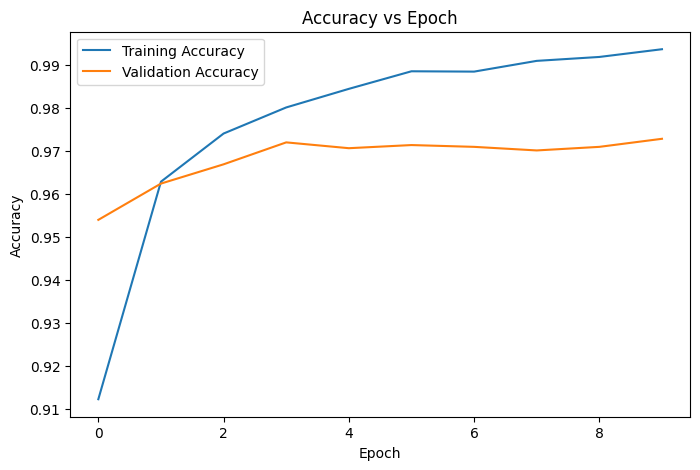

In [27]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

plt.savefig("../images/accuracy_vs_epoch.png", dpi=300, bbox_inches="tight")

plt.show()

### Loss vs Epoch

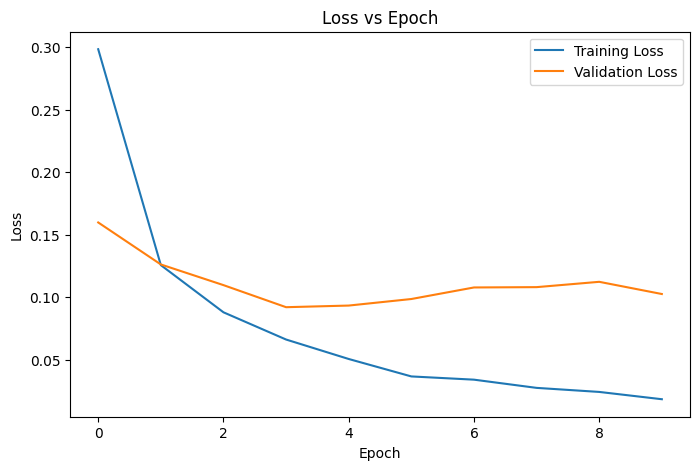

In [28]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.savefig("../images/loss_vs_epoch.png", dpi=300, bbox_inches="tight")

plt.show()

### Observations

1. The ANN achieved a high classification accuracy on the MNIST test dataset, demonstrating its effectiveness in recognizing handwritten digits.
2. The confusion matrix shows that most digits were correctly classified, with only a small number of misclassifications between visually similar digits.
3. The training and validation accuracy increased steadily over the 10 epochs, while the loss decreased, indicating that the model learned effectively.
4. The model architecture with two hidden layers successfully captured complex patterns in the handwritten digit images, resulting in strong overall performance.

## 8: Conclusion

This assignment successfully developed an Artificial Neural Network (ANN) to recognize handwritten digits from the MNIST dataset. After preprocessing the data by normalizing pixel values and applying one-hot encoding, the ANN was trained using two hidden layers with ReLU activation and a Softmax output layer. The model achieved high classification performance, demonstrating that ANN is highly effective for image recognition tasks. Hidden layers play an important role in learning complex patterns and extracting meaningful features from the input data. One major advantage of Deep Learning over traditional Machine Learning is its ability to automatically learn hierarchical features from raw data without manual feature engineering. A limitation of ANN is that it requires a large amount of training data and computational resources to achieve optimal performance.